In [1]:
import sys
from os.path import dirname, realpath, join
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import kendalltau

from Functions.method_exp import PDRankSolver
from Functions.data_handle import Data
from Functions.data_handle_exp import DataExp
from Functions.other_methods.BordaCount import BordaCount
import Functions.other_methods.lsr as lsr
import Functions.other_methods.Hodge as Hodge
from tqdm.auto import tqdm

In [2]:
from dataclasses import dataclass, asdict

@dataclass
class DataConfig:
    """Number of items"""
    m: int = 30
    """Number of comparisons"""
    n: int = 1000
    """Type of noise in labels: 'constant', 'None' (no noise), 'BTL' (Bradley-Terry-Luce model)"""
    noise_type: str = 'constant'
    """Level of noise for noise_type"""
    noise_level: float | np.ndarray = 0.1
    """Graph connective enforced: 'no', 'connected', 'strongly'"""
    connectivity: str = 'connected'
    """Scores interval for BTL model"""
    bt_interval: tuple[float, float] | None = None

In [3]:
n_std_trial = np.linspace(0.3, 15, num=20, endpoint=True)
n_simulation_per_trial = 20

# Parameters for PD-Rank (additional parameters can be consulted in the PDRank class. We recommend using the default values)
# epsilon_out = 1e-2 # epsilon for stopping criterion of outer iterations. Recommended values of 1e-2 for m<500, 1e-1 otherwise
# epsilon_in  = 1e-2 # epsilon for stopping criterion of inner iterations. Recommended values of 1e-2 for m<500, 1e-3 otherwise

In [4]:
def solve_ranking(data: DataExp, algo_name = "PDRank", **algo_config):
    other = {"algo_config": algo_config}
    if algo_name == "PDRank":
        if data.noise_type != 'random_annotator':
            A, w_obs = data.get_Areduced_w()
        else:
            A = data.get_A_full()
            w_obs = None
        epsilon_out = algo_config.get('epsilon_out', 1e-2)
        epsilon_in  = algo_config.get('epsilon_in', 1e-2)
        return_solution_path = algo_config.get('return_solution_path', False)
        pdrank = PDRankSolver(epsilon_in=epsilon_in, epsilon_out=epsilon_out)
        x = pdrank.solve(A, w_obs=w_obs, return_solution_path=return_solution_path) # solve the problem
        if return_solution_path:
            x, ws, xs = x
            other["weight_path"] = ws
            other["score_path"] = xs
        return x, other
    elif algo_name == "Borda":
        x = -BordaCount(data.get_P_rel())
        return x, other
    elif algo_name == "LSR":
        x = lsr.lsr(data.m, np.repeat(data.pairs_reduced, data.pairs_weight, axis=0).tolist())
        return x, other
    elif algo_name == "I-LSR":
        x = lsr.lsr(data.m, np.repeat(data.pairs_reduced, data.pairs_weight, axis=0).tolist())
        return x, other
    elif algo_name == "HodgeRank":
        x = -Hodge.geo_rank(data.get_rank_diff_matrix())
        return x, other

In [5]:
def run_simulation(data_config,
                   algo_name="PDRank",
                   algo_config=None,
                   return_data=False,
                   return_other=False,
                   **kwargs):
    config = {
        'algo_name': algo_name
    }
    if algo_config is None:
        algo_config = {}
    data_conf = asdict(data_config)
    for key, value in kwargs.items():
        if key in data_conf:
            data_conf[key] = value
    config.update(data_conf)
    config.update(algo_config)
    for key, value in kwargs.items():
        if key not in config:
            config[key] = value
    # Generate comparison data with the required parameters
    data = DataExp(**data_conf, demo=False)
    x_gt = data.x
    x, other = solve_ranking(data, algo_name, **algo_config)
    kendall_tau = kendalltau(x_gt, x).statistic
    config['kendall_tau'] = kendall_tau
    
    if not return_data and not return_other:
        return config
        
    returns = [config]
    if return_data:
        returns.append(data)
    if return_other:
        returns.append(other)
        
    return tuple(returns)

In [8]:
%%time
run_simulation(DataConfig(), "HodgeRank", {}, n = 6000)

CPU times: user 34.4 ms, sys: 4.04 ms, total: 38.5 ms
Wall time: 38.3 ms


{'algo_name': 'HodgeRank',
 'm': 30,
 'n': 6000,
 'noise_type': 'constant',
 'noise_level': 0.1,
 'connectivity': 'connected',
 'bt_interval': None,
 'kendall_tau': np.float64(0.9816091954022989)}

In [27]:
def run_exp():
    pass

In [9]:
from joblib import Parallel, delayed
# Parallel version of run_exp (for speed purpose)
def run_exp_parallel(m, n_std_trial, n_simulation_per_trial, algo_name, algo_config, data_config, **kwargs):
    n_comparisons = (n_std_trial*m*(m-1)/2).astype(int) # number of comparisons
    result = Parallel(n_jobs=4, verbose=10)(delayed(run_simulation)(data_config, algo_name, algo_config, n = n_pairs, **kwargs) for _ in range(n_simulation_per_trial) for n_pairs in n_comparisons)
    return result

In [11]:
m = 30
n_std_trial = np.linspace(0.3, 15, num=20, endpoint=True)
n_simulation_per_trial = 20

In [32]:
# Can use the sequential version run_exp if you don't have joblib
configs = [
    {
        "algo_name": "PDRank", 
        "algo_config": {}, 
        "data_config": DataConfig(noise_type='constant', noise_level=0.1)
    },
    {
        "algo_name": "PDRank", 
        "algo_config": {}, 
        "data_config": DataConfig(noise_type='random_annotator', noise_level=np.array([0.1, 0.15, 0.2, 0.4]))
    }
]
results = []
for config in configs:
    result = run_exp_parallel(m, n_std_trial, n_simulation_per_trial, **config)
    results.append(pd.DataFrame(result))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.8s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    2.4s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    2.7s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:    3.6s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    4.0s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:    4.5s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:    4.9s
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:    5.6s
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:    6.2s
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:    6.9s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    7.7s
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:    8.4s
[Parallel(

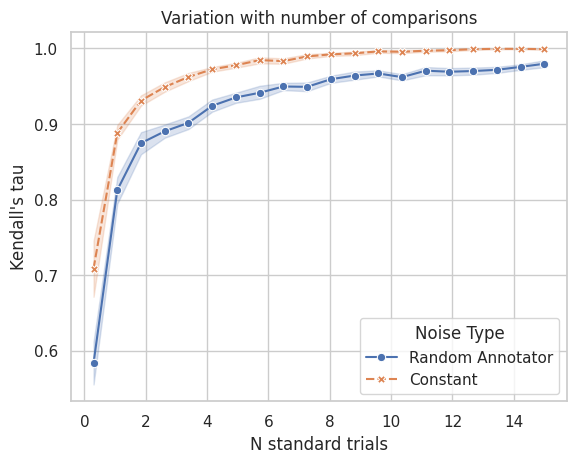

In [36]:
df = pd.concat(results).sort_values(by='n')
df['n_std_trial'] = df['n'] * 2 / (m*(m-1))
sns.set(style="whitegrid")
g = sns.lineplot(data=df, x='n_std_trial', y='kendall_tau', hue='noise_type', style='noise_type', markers=True)
g.set_title('Variation with number of comparisons')
g.set_xlabel("N standard trials")
g.set_ylabel("Kendall's tau")
handles, labels = g.get_legend_handles_labels()
g.legend(handles, ["Random Annotator", "Constant"], title="Noise Type")

In [10]:
g.get_figure().savefig('test_rnd_annotator_result_01.pdf', format='pdf', bbox_inches='tight')

In [12]:
r_annotator_noise = np.array([0.1, 0.5, 0.2, 0.4])
configs = [
    {
        "algo_name": algo, 
        "algo_config": {}, 
        "data_config": DataConfig(noise_type='random_annotator', noise_level=r_annotator_noise, connectivity = "strongly")
    }
    for algo in ["PDRank", "Borda", "LSR", "HodgeRank"]
]
results = []
for config in configs:
    result = run_exp_parallel(m, n_std_trial, n_simulation_per_trial, **config)
    results.append(pd.DataFrame(result))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    3.6s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    4.0s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    5.1s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    5.8s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    7.0s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    8.0s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:    9.1s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:   10.1s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:   11.5s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:   12.4s
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:   13.8s
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:   15.5s
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:   17.2s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:   18.7s
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:   20.5s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:   22.1s
[Parallel(n_jobs=4)]: Do

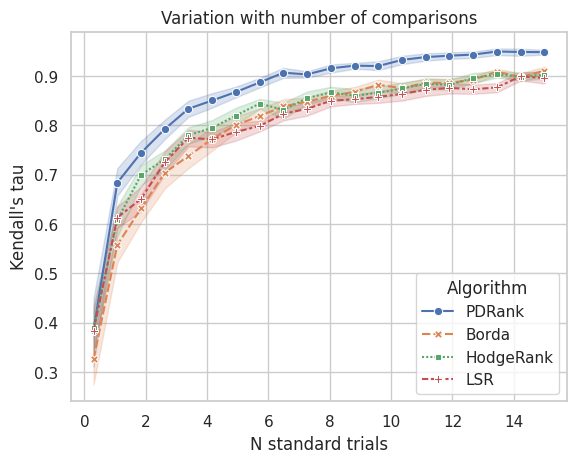

In [13]:
df = pd.concat(results).sort_values(by='n')
df['n_std_trial'] = df['n'] * 2 / (m*(m-1))
sns.set(style="whitegrid")
g = sns.lineplot(data=df, x='n_std_trial', y='kendall_tau', hue='algo_name', style='algo_name', markers=True)
g.set_title('Variation with number of comparisons')
g.set_xlabel("N standard trials")
g.set_ylabel("Kendall's tau")
handles, labels = g.get_legend_handles_labels()
g.legend(handles, labels, title="Algorithm")

In [11]:
num_std_trial = 3
config, data, ws, xs = run_simulation(m,
                   int(num_std_trial * m * (m - 1) / 2),
                   noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in, return_data=True, return_solution_path=True)
config['kendall_tau']

np.float64(0.9448275862068967)

In [12]:
A, w_obs = data.get_Areduced_w()
noisy_idx = np.nonzero(A @ data.x < 0)[0]
A.shape

(517, 30)

In [13]:
df = pd.DataFrame(ws.T).reset_index()
df = pd.melt(df, id_vars='index').rename(columns={'index': 'n', 'variable': 'iteration'})
df['noisy'] = df['n'].isin(noisy_idx)
df

,n,iteration,value,noisy
0,0,0,1.000000,False
1,1,0,1.000000,False
2,2,0,1.000000,False
3,3,0,1.000000,False
4,4,0,1.000000,False
...,...,...,...,...
6199,512,11,11.960609,False
6200,513,11,0.029394,True
6201,514,11,0.066804,True
6202,515,11,41.084954,False


In [14]:
# iteration, value, n, noisy?
test_noisy_idx = df[df['noisy'] == True].n.unique().sort()
np.array_equal(test_noisy_idx, noisy_idx.sort())

True

Text(0.5, 1.0, 'Evolution of weight values by outer iteration')

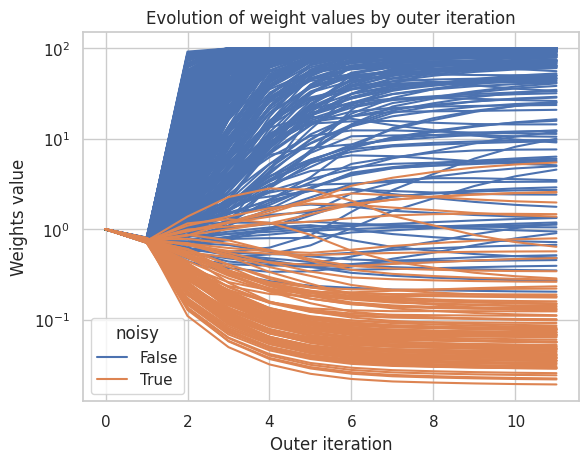

In [15]:
g = sns.lineplot(data=df, x='iteration', y='value', units='n', hue='noisy', 
                 estimator=None)
plt.semilogy()
g.set_xlabel("Outer iteration")
g.set_ylabel("Weights value")
g.set_title("Evolution of weight values by outer iteration")

In [44]:
# For random_annotator noise type
num_std_trial = 2
config, data, ws, xs = run_simulation(m,
                   int(num_std_trial * m * (m - 1) / 2),
                   noise_type=configs[1]['noise_type'], 
                   noise_level=np.linspace(1, 5, num=5) / 10, 
                    return_data=True, return_solution_path=True)
config['kendall_tau']

np.float64(0.871264367816092)

In [45]:
A, annotators = data.get_A_full(return_annotators=True)
noisy_idx = np.nonzero(A @ data.x < 0)[0]
noisy_idx_pred = np.nonzero(A @ xs[-1] < 0)[0]
A.shape, noisy_idx.shape, noisy_idx_pred.shape, annotators.shape

((870, 30), (239,), (241,), (870,))

In [46]:
df = pd.DataFrame(ws.T).reset_index()
# n is the n-th pair
df = pd.melt(df, id_vars='index').rename(columns={'index': 'n', 'variable': 'iteration'})
df['noisy'] = df['n'].isin(noisy_idx)
df['noisy_pred'] = df['n'].isin(noisy_idx_pred)
df['annotator'] = annotators[df['n']]
df

,n,iteration,value,noisy,noisy_pred,annotator
0,0,0,1.000000,False,False,4
1,1,0,1.000000,False,False,2
2,2,0,1.000000,False,False,0
3,3,0,1.000000,False,False,1
4,4,0,1.000000,False,False,2
...,...,...,...,...,...,...
9565,865,10,21.860745,False,False,2
9566,866,10,21.860745,False,False,2
9567,867,10,21.860745,False,False,4
9568,868,10,97.026552,False,False,1


Text(0.5, 1.0, 'Evolution of weight values by outer iteration (Random Annotator Noise)')

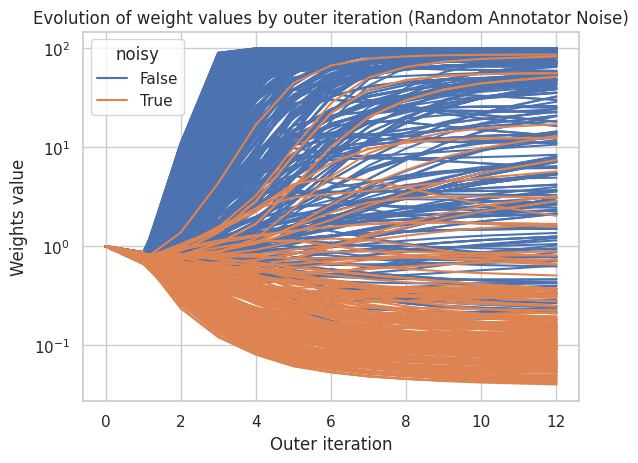

In [33]:
g = sns.lineplot(data=df, x='iteration', y='value', units='n', hue='noisy', 
                 estimator=None)
plt.semilogy()
g.set_xlabel("Outer iteration")
g.set_ylabel("Weights value")
g.set_title("Evolution of weight values by outer iteration (Random Annotator Noise)")

In [34]:
g.get_figure().savefig('rnd_annotator_weight_evo.pdf', format='pdf', bbox_inches='tight')

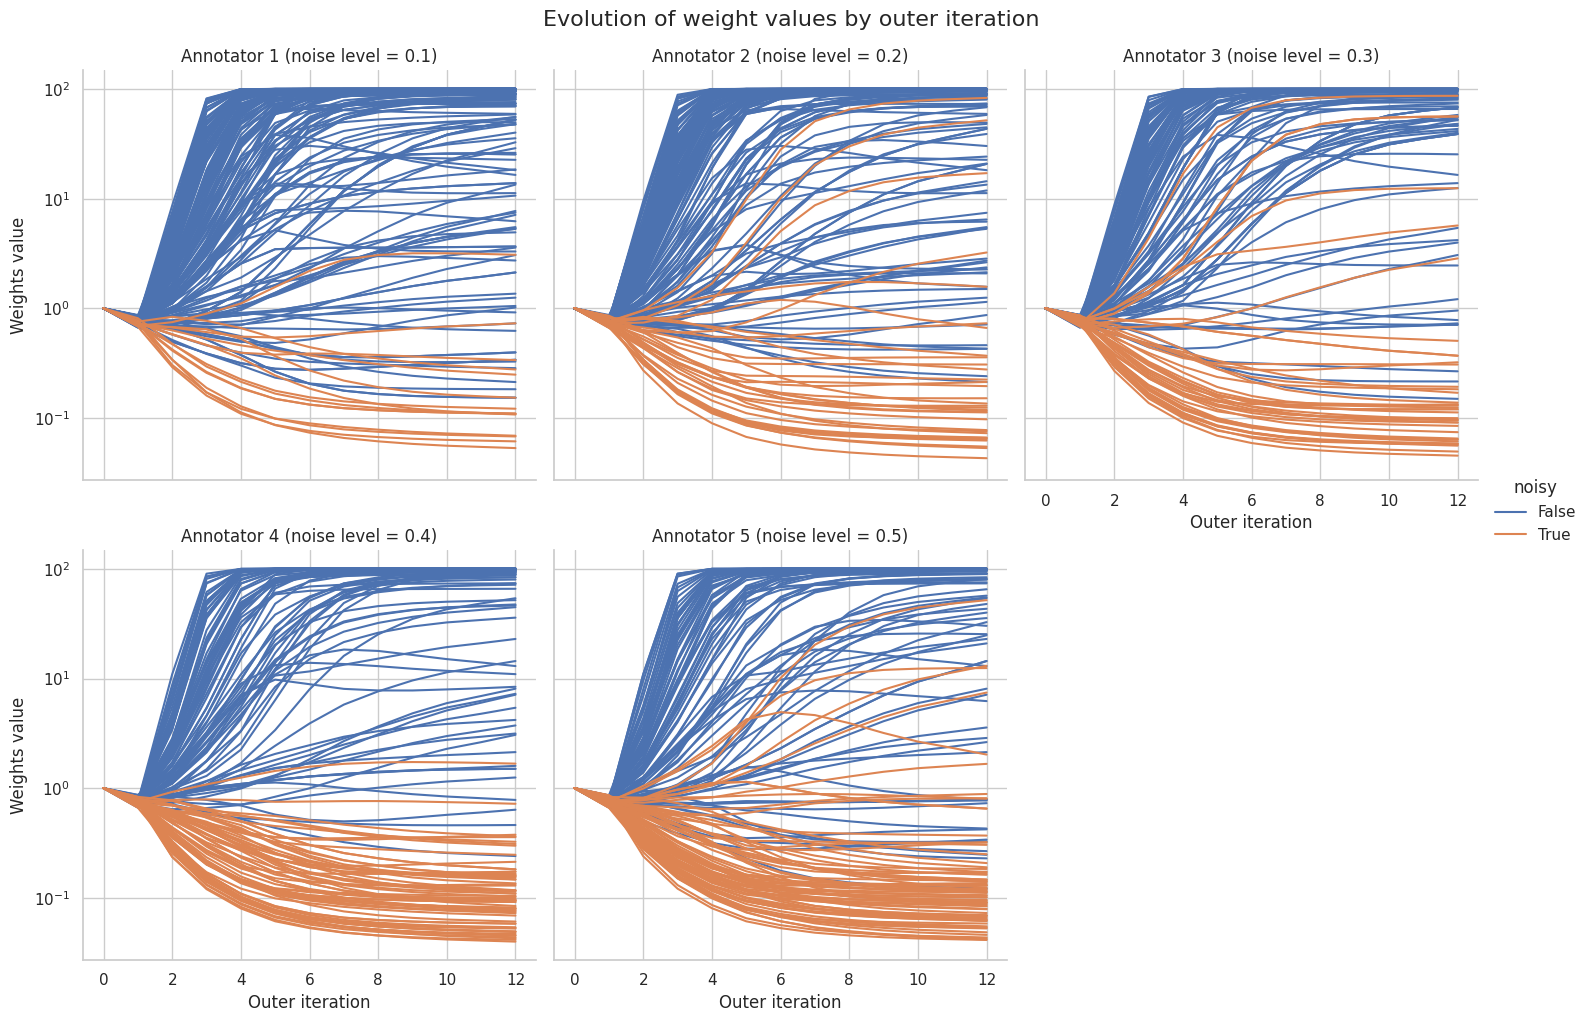

In [35]:
g = sns.relplot(
    data=df, x='iteration', y='value', units='n', hue='noisy',
    col='annotator',
    col_wrap=3,
    estimator=None,
    kind="line"
)
plt.semilogy()
g.set_xlabels("Outer iteration")
g.set_ylabels("Weights value")
g.fig.suptitle("Evolution of weight values by outer iteration", fontsize=16, y=1.02)
for col_val, ax in g.axes_dict.items():
    ax.set_title(f"Annotator {col_val + 1} (noise level = {config['noise_level'][col_val]})")

In [22]:
g.fig.savefig('rnd_annotator_weight_evo_by_annotator.pdf', format='pdf', bbox_inches='tight')

In [60]:
df_noisy = df[df.iteration == df.iteration.max()].groupby(["annotator", "noisy"]).size().unstack()
df_noisy['noisy_percent'] = df_noisy[True] / (df_noisy[True] + df_noisy[False])
df_noisy

noisy,False,True,noisy_percent
annotator,,,
0,159,17,0.096591
1,149,29,0.162921
2,127,51,0.286517
3,107,71,0.398876
4,89,71,0.443750


In [62]:
df_noisy = df[df.iteration == 0].groupby(["annotator", "noisy_pred"]).size().unstack()
df_noisy['noisy_percent'] = df_noisy[True] / (df_noisy[True] + df_noisy[False])
df_noisy

noisy_pred,False,True,noisy_percent
annotator,,,
0,154,22,0.125000
1,145,33,0.185393
2,127,51,0.286517
3,107,71,0.398876
4,96,64,0.400000


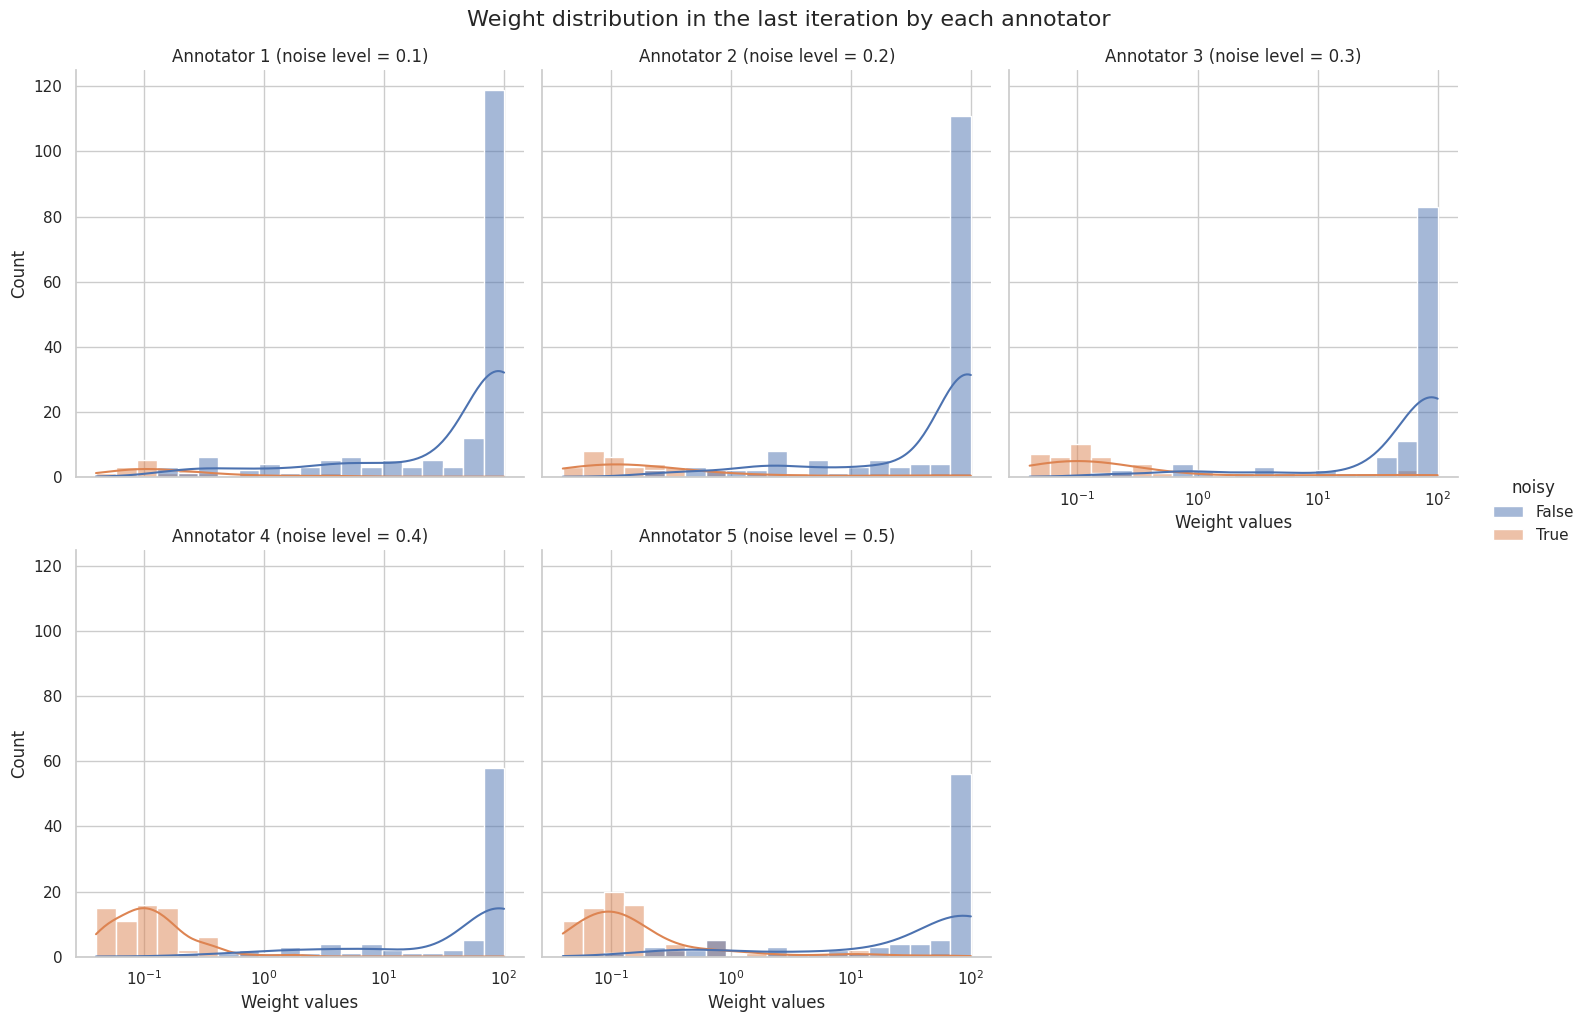

In [24]:
g = sns.displot(data = df[df.iteration == df.iteration.max()], 
                x = "value", 
                hue = "noisy", 
                col = "annotator", 
                col_wrap=3,
                bins=20,
                kde=True,
                log_scale=True)
g.set_xlabels("Weight values")
g.fig.suptitle("Weight distribution in the last iteration by each annotator", fontsize=16, y=1.02)
for col_val, ax in g.axes_dict.items():
    ax.set_title(f"Annotator {col_val + 1} (noise level = {config['noise_level'][col_val]})")

In [25]:
g.fig.savefig('rnd_annotator_weight_dist_last_iter.pdf', format='pdf', bbox_inches='tight')

In [246]:
def random_fixed_mean(k, m, upper = 1):
    target_sum = k * m
    while True:
        x = np.random.dirichlet(np.ones(k)) * target_sum
        # Check if ALL numbers satisfy the upper bound 'a'
        if np.all(x <= upper):
            return x

n_annotator_min = 3
n_annotator_max = 6
fixed_noise_level = 0.4
configs = [{
    "noise_type": 'random_annotator', 
    "noise_level": random_fixed_mean(n, fixed_noise_level), 
    "others": {"n_annotator": f"{n}"}} for n in range(n_annotator_min, n_annotator_max + 1)]

print([c['noise_level'] for c in configs])
results = []
for config in configs:
    result = run_exp_parallel(m, n_std_trial, n_simulation_per_trial, **config)
    results.append(pd.DataFrame(result))

[array([0.37961534, 0.67349569, 0.14688897]), array([0.05974855, 0.84149415, 0.24440853, 0.45434876]), array([0.73931915, 0.2083264 , 0.46445403, 0.18618693, 0.4017135 ]), array([0.24841473, 0.50425911, 0.18854053, 0.68994776, 0.43544541,
       0.33339246])]


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.3s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.5s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    2.2s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    2.6s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    3.0s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:    3.4s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    3.9s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:    4.7s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:    5.2s
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:    5.9s
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:    6.7s
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:    7.4s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    8.1s
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:    8.9s
[Parallel(

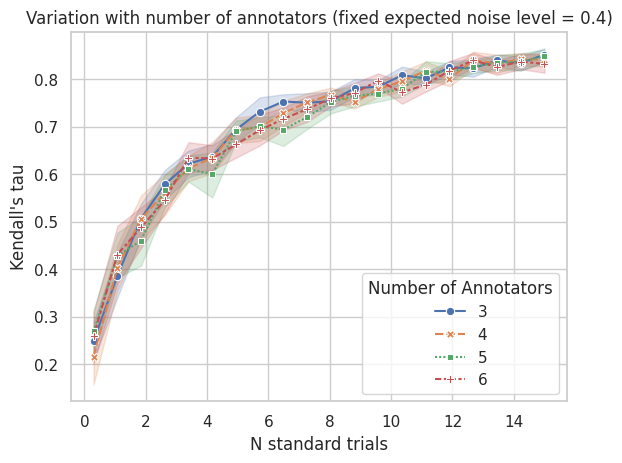

In [250]:
df = pd.concat(results).sort_values(by=['n_pairs', 'n_annotator'])
df['n_std_trial'] = df['n_pairs'] * 2 / (m*(m-1))
sns.set(style="whitegrid")
g = sns.lineplot(data=df, x='n_std_trial', y='kendall_tau', hue='n_annotator', style='n_annotator', markers=True)
g.set_title(f'Variation with number of annotators (fixed expected noise level = {fixed_noise_level})')
g.set_xlabel("N standard trials")
g.set_ylabel("Kendall's tau")
handles, labels = g.get_legend_handles_labels()
g.legend(title="Number of Annotators")

In [251]:
g.get_figure().savefig('variation_with_n_annotator.pdf', format='pdf', bbox_inches='tight')

In [252]:
n_annotator = 3
noise_levels = [0.2, 0.3, 0.4, 0.5]
configs = [{
    "noise_type": 'random_annotator', 
    "noise_level": random_fixed_mean(n_annotator, level), 
    "others": {"noise_level_mean": f"{level}"}} for level in noise_levels]
results = []
for config in configs:
    result = run_exp_parallel(m, n_std_trial, n_simulation_per_trial, **config)
    results.append(pd.DataFrame(result))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Batch computation too fast (0.10663032531738281s.) Setting batch_size=2.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done  12 tasks      | elapsed:    0.7s
[Parallel(n_jobs=4)]: Done  26 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done  40 tasks      | elapsed:    2.2s
[Parallel(n_jobs=4)]: Done  58 tasks      | elapsed:    3.1s
[Parallel(n_jobs=4)]: Done  76 tasks      | elapsed:    4.2s
[Parallel(n_jobs=4)]: Done  98 tasks      | elapsed:    5.4s
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:    6.5s
[Parallel(n_jobs=4)]: Done 146 tasks      | elapsed:    7.8s
[Parallel(n_jobs=4)]: Done 172 tasks      | elapsed:    9.2s
[Parallel(n_jobs=4)]: Done 202 tasks      | elapsed:   10.7s
[Parallel(n_jobs=4)]: Done 232 tasks      | elapsed:   12.6s
[Parallel(n_jobs=4)]: Done 266 tasks      | elapsed:   14.4s
[Parallel(n_jobs=4)]: Done 300 tasks 

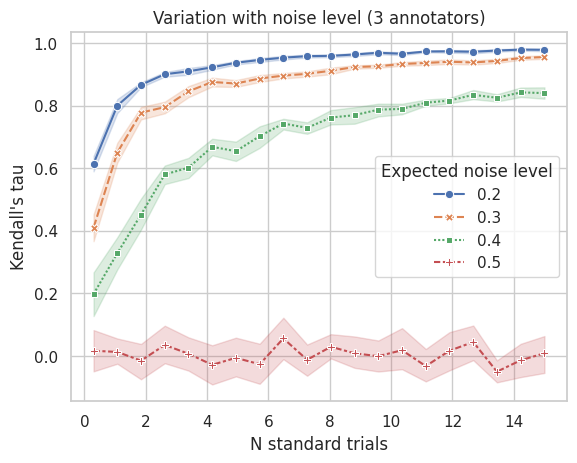

In [254]:
df = pd.concat(results).sort_values(by=['n_pairs', 'noise_level_mean'])
df['n_std_trial'] = df['n_pairs'] * 2 / (m*(m-1))
sns.set(style="whitegrid")
g = sns.lineplot(data=df, x='n_std_trial', y='kendall_tau', hue='noise_level_mean', style='noise_level_mean', markers=True)
g.set_title(f'Variation with noise level ({n_annotator} annotators)')
g.set_xlabel("N standard trials")
g.set_ylabel("Kendall's tau")
handles, labels = g.get_legend_handles_labels()
g.legend(title="Expected noise level")

In [255]:
g.get_figure().savefig('variation_with_expected_noise_level.pdf', format='pdf', bbox_inches='tight')